In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/FAO_MK (1).csv"

df = pd.read_csv(file_path)

df.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,UNIT_MULT,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AFG,Afghanistan,FAO_MK_22008,Gross Domestic Product,_T,...,6,Millions,NUMBER,Number (real number),602,CCYY,A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AFG,Afghanistan,FAO_MK_22008,Gross Domestic Product,_T,...,6,Millions,NUMBER,Number (real number),602,CCYY,A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AFG,Afghanistan,FAO_MK_22008,Gross Domestic Product,_T,...,6,Millions,NUMBER,Number (real number),602,CCYY,A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AFG,Afghanistan,FAO_MK_22008,Gross Domestic Product,_T,...,6,Millions,NUMBER,Number (real number),602,CCYY,A,Normal value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AFG,Afghanistan,FAO_MK_22008,Gross Domestic Product,_T,...,6,Millions,NUMBER,Number (real number),602,CCYY,A,Normal value,PU,Public


In [ ]:
df.shape

(72198, 37)

In [ ]:
df.columns

Index(['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA',
       'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL',
       'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL',
       'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1',
       'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_2_LABEL',
       'COMP_BREAKDOWN_3', 'COMP_BREAKDOWN_3_LABEL', 'TIME_PERIOD',
       'OBS_VALUE', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'UNIT_MULT',
       'UNIT_MULT_LABEL', 'UNIT_TYPE', 'UNIT_TYPE_LABEL', 'TIME_FORMAT',
       'TIME_FORMAT_LABEL', 'OBS_STATUS', 'OBS_STATUS_LABEL', 'OBS_CONF',
       'OBS_CONF_LABEL'],
      dtype='object')

In [ ]:
print(df.isnull().sum())

STRUCTURE                 0
STRUCTURE_ID              0
ACTION                    0
FREQ                      0
FREQ_LABEL                0
REF_AREA                  0
REF_AREA_LABEL            0
INDICATOR                 0
INDICATOR_LABEL           0
SEX                       0
SEX_LABEL                 0
AGE                       0
AGE_LABEL                 0
URBANISATION              0
URBANISATION_LABEL        0
UNIT_MEASURE              0
UNIT_MEASURE_LABEL        0
COMP_BREAKDOWN_1          0
COMP_BREAKDOWN_1_LABEL    0
COMP_BREAKDOWN_2          0
COMP_BREAKDOWN_2_LABEL    0
COMP_BREAKDOWN_3          0
COMP_BREAKDOWN_3_LABEL    0
TIME_PERIOD               0
OBS_VALUE                 0
DATABASE_ID               0
DATABASE_ID_LABEL         0
UNIT_MULT                 0
UNIT_MULT_LABEL           0
UNIT_TYPE                 0
UNIT_TYPE_LABEL           0
TIME_FORMAT               0
TIME_FORMAT_LABEL         0
OBS_STATUS                0
OBS_STATUS_LABEL          0
OBS_CONF            

In [ ]:
df.describe()

,TIME_PERIOD,OBS_VALUE,UNIT_MULT,TIME_FORMAT
count,72198.000000,7.219800e+04,72198.0,72198.0
mean,1999.191806,1.941425e+07,6.0,602.0
std,15.593923,1.082273e+09,0.0,0.0
min,1970.000000,0.000000e+00,6.0,602.0
25%,1986.000000,6.048361e+02,6.0,602.0
50%,2001.000000,4.452770e+03,6.0,602.0
75%,2013.000000,4.018218e+04,6.0,602.0
max,2024.000000,1.978596e+11,6.0,602.0


In [ ]:
#See what indicators we are working with
print(df['INDICATOR_LABEL'].unique())

['Gross Domestic Product' 'Value Added (Agriculture)'
 'Value Added (Agriculture, Forestry and Fishing)'
 'Value Added (Manufacture of food and beverages)']


In [ ]:
#Pivoting the data

#Select the indicators
selected_indicators = ['Value Added (Agriculture)', 'Gross Domestic Product','Value Added (Agriculture, Forestry and Fishing)','Value Added (Manufacture of food and beverages)']
#Filter
df_filtered = df[df['INDICATOR_LABEL'].isin(selected_indicators)]
#Pivot
df_ml = df_filtered.pivot_table(index=['REF_AREA_LABEL', 'TIME_PERIOD'],
                               columns='INDICATOR_LABEL',
                               values='OBS_VALUE').reset_index()
pd.set_option('display.expand_frame_repr', False)
print(df_ml.head())

INDICATOR_LABEL REF_AREA_LABEL  TIME_PERIOD  Gross Domestic Product  Value Added (Agriculture)  Value Added (Agriculture, Forestry and Fishing)  Value Added (Manufacture of food and beverages)
0                  Afghanistan         1970             4134.581061                        NaN                                      2955.808471                                              NaN
1                  Afghanistan         1971             4153.501989                        NaN                                      2868.939012                                              NaN
2                  Afghanistan         1972             3494.838777                        NaN                                      2720.817527                                              NaN
3                  Afghanistan         1973             3627.941810                        NaN                                      2924.956909                                              NaN
4                  Afghanistan     

In [ ]:
#Oragnise
df_ml = df_ml.sort_values(['REF_AREA_LABEL', 'TIME_PERIOD'])
#Filling the gapsa using interpolation to 'connect the dots' for missing years
# We group by country so we don't accidentally mix one country's data with another
df_ml_cleaned = df_ml.groupby('REF_AREA_LABEL', group_keys=False).apply(
    lambda country_data: country_data.interpolate(method='linear', limit_direction='both')
)
#Clean up: Delete any rows that are still empty (where there were no dots to connect)
df_ml_final = df_ml_cleaned.dropna()
print("Missing values per column:")
print(df_ml_final.isnull().sum())



Missing values per column:
INDICATOR_LABEL
REF_AREA_LABEL                                     0
TIME_PERIOD                                        0
Gross Domestic Product                             0
Value Added (Agriculture)                          0
Value Added (Agriculture, Forestry and Fishing)    0
Value Added (Manufacture of food and beverages)    0
dtype: int64


### Feature Engineering: Creating More Informative Inputs

Feature engineering involves creating new input features from existing data to improve the performance of machine learning models. For time-series data like ours, this can include:

1.  **Lagged Features:** Past values of a variable that can help predict its future values.
2.  **Rolling Statistics:** Moving averages or standard deviations over a period, capturing trends or volatility.

Let's add some lagged features (1-year) and rolling means (3-year) to our dataset for each of our key economic indicators. We will do this before splitting the data to ensure these new features are consistent across the dataset.

In [ ]:
df_ml_final = df_ml_final.sort_values(by=['REF_AREA_LABEL', 'TIME_PERIOD'])

# Define the indicator columns for which we want to create new features
# Now excluding 'Gross Domestic Product' from feature engineering as requested.
indicator_cols_for_fe = [
    'Value Added (Agriculture)',
    'Value Added (Agriculture, Forestry and Fishing)',
    'Value Added (Manufacture of food and beverages)'
]

# Create lagged features (e.g., previous year's value)
for col in indicator_cols_for_fe:
    df_ml_final[f'{col}_lag1'] = df_ml_final.groupby('REF_AREA_LABEL')[col].shift(1)

# Create rolling mean features (e.g., 3-year rolling average)
for col in indicator_cols_for_fe:
    df_ml_final[f'{col}_rollmean3'] = df_ml_final.groupby('REF_AREA_LABEL')[col].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean()
    )

# Drop rows with NaN values that result from lagging/rolling (typically the first few years per country)
df_ml_final_fe = df_ml_final.dropna()

print("New features added to df_ml_final_fe:")
display(df_ml_final_fe.head())

New features added to df_ml_final_fe:


INDICATOR_LABEL,REF_AREA_LABEL,TIME_PERIOD,Gross Domestic Product,Value Added (Agriculture),"Value Added (Agriculture, Forestry and Fishing)",Value Added (Manufacture of food and beverages),Value Added (Agriculture)_lag1,"Value Added (Agriculture, Forestry and Fishing)_lag1",Value Added (Manufacture of food and beverages)_lag1,Value Added (Agriculture)_rollmean3,"Value Added (Agriculture, Forestry and Fishing)_rollmean3",Value Added (Manufacture of food and beverages)_rollmean3
784,Bangladesh,1971,26777.917589,631789.198106,9220.913511,85509.999493,631789.198106,10028.925289,85509.999493,631789.198106,9624.919400,85509.999493
785,Bangladesh,1972,24061.147527,631789.198106,9353.354041,85509.999493,631789.198106,9220.913511,85509.999493,631789.198106,9534.397614,85509.999493
786,Bangladesh,1973,33315.623178,631789.198106,12694.047221,85509.999493,631789.198106,9353.354041,85509.999493,631789.198106,10422.771591,85509.999493
787,Bangladesh,1974,46016.294164,631789.198106,18136.592002,85509.999493,631789.198106,12694.047221,85509.999493,631789.198106,13394.664421,85509.999493
788,Bangladesh,1975,67106.541227,631789.198106,30932.231321,85509.999493,631789.198106,18136.592002,85509.999493,631789.198106,20587.623514,85509.999493


### Data Re-preparation with Feature-Engineered Data

Now that we have engineered new features, we should re-split the data, scale it, and prepare it for training our models. We will apply a log transformation to the target variable (`Gross Domestic Product`) to handle its skewed distribution, which often improves model performance.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Separate the "Clue" from the "Answer" using the new feature-engineered DataFrame
# X_fe includes new features, excluding GDP's own lagged/rolled versions as it's not engineered.
X_fe = df_ml_final_fe[[
    'Value Added (Agriculture)',
    'Value Added (Agriculture, Forestry and Fishing)',
    'Value Added (Manufacture of food and beverages)',
    'Value Added (Agriculture)_lag1',
    'Value Added (Agriculture, Forestry and Fishing)_lag1',
    'Value Added (Manufacture of food and beverages)_lag1',
    'Value Added (Agriculture)_rollmean3',
    'Value Added (Agriculture, Forestry and Fishing)_rollmean3',
    'Value Added (Manufacture of food and beverages)_rollmean3'
]]

y_fe_original = df_ml_final_fe['Gross Domestic Product']

# Apply log transformation to the target variable (`Gross Domestic Product`)
y_fe_log_transformed = np.log1p(y_fe_original)

# Split the feature-engineered data for the log-transformed target
X_train_fe_log, X_test_fe_log, y_train_fe_log, y_test_fe_log = train_test_split(X_fe, y_fe_log_transformed, test_size=0.2, random_state=42)

# Scalers for the feature-engineered data and log-transformed target
scaler_x_fe_log = MinMaxScaler()
scaler_y_fe_log = MinMaxScaler()

# Shrink the indicator clues
X_train_scaled_fe_log = scaler_x_fe_log.fit_transform(X_train_fe_log)
X_test_scaled_fe_log = scaler_x_fe_log.transform(X_test_fe_log)

# Shrink the GDP answers
y_train_scaled_fe_log = scaler_y_fe_log.fit_transform(y_train_fe_log.values.reshape(-1, 1))
y_test_scaled_fe_log = scaler_y_fe_log.transform(y_test_fe_log.values.reshape(-1, 1))

print("Step 1 Complete: The feature-engineered data is split, scaled, and ready for retraining!")

Step 1 Complete: The feature-engineered data is split, scaled, and ready for retraining!


In [ ]:
display(df_ml_final.head())


INDICATOR_LABEL,REF_AREA_LABEL,TIME_PERIOD,Gross Domestic Product,Value Added (Agriculture),"Value Added (Agriculture, Forestry and Fishing)",Value Added (Manufacture of food and beverages),Value Added (Agriculture)_lag1,"Value Added (Agriculture, Forestry and Fishing)_lag1",Value Added (Manufacture of food and beverages)_lag1,Value Added (Agriculture)_rollmean3,"Value Added (Agriculture, Forestry and Fishing)_rollmean3",Value Added (Manufacture of food and beverages)_rollmean3
783,Bangladesh,1970,27983.002150,631789.198106,10028.925289,85509.999493,NaN,NaN,NaN,631789.198106,10028.925289,85509.999493
784,Bangladesh,1971,26777.917589,631789.198106,9220.913511,85509.999493,631789.198106,10028.925289,85509.999493,631789.198106,9624.919400,85509.999493
785,Bangladesh,1972,24061.147527,631789.198106,9353.354041,85509.999493,631789.198106,9220.913511,85509.999493,631789.198106,9534.397614,85509.999493
786,Bangladesh,1973,33315.623178,631789.198106,12694.047221,85509.999493,631789.198106,9353.354041,85509.999493,631789.198106,10422.771591,85509.999493
787,Bangladesh,1974,46016.294164,631789.198106,18136.592002,85509.999493,631789.198106,12694.047221,85509.999493,631789.198106,13394.664421,85509.999493


In [ ]:
df_ml_final.describe()

INDICATOR_LABEL,TIME_PERIOD,Gross Domestic Product,Value Added (Agriculture),"Value Added (Agriculture, Forestry and Fishing)",Value Added (Manufacture of food and beverages),Value Added (Agriculture)_lag1,"Value Added (Agriculture, Forestry and Fishing)_lag1",Value Added (Manufacture of food and beverages)_lag1,Value Added (Agriculture)_rollmean3,"Value Added (Agriculture, Forestry and Fishing)_rollmean3",Value Added (Manufacture of food and beverages)_rollmean3
count,1541.000000,1.541000e+03,1.541000e+03,1.541000e+03,1.541000e+03,1.510000e+03,1.510000e+03,1.510000e+03,1.541000e+03,1.541000e+03,1.541000e+03
mean,1998.835172,7.849250e+06,1.198568e+06,9.372561e+05,4.909640e+05,1.127912e+06,8.379163e+05,4.803176e+05,1.119595e+06,8.252057e+05,4.785010e+05
std,15.499353,4.098258e+07,5.149439e+06,5.387560e+06,1.999837e+06,4.678551e+06,4.735970e+06,1.953297e+06,4.608456e+06,4.698099e+06,1.944913e+06
min,1970.000000,2.324469e+02,8.751148e+00,6.863025e+00,3.346237e+00,8.751148e+00,6.863025e+00,3.346237e+00,9.854948e+00,6.863025e+00,3.518815e+00
25%,1986.000000,2.149282e+04,2.341020e+03,1.944170e+03,3.483112e+03,2.308809e+03,1.890440e+03,3.310133e+03,2.333069e+03,1.884447e+03,3.345797e+03
50%,2000.000000,1.074867e+05,1.989497e+04,1.187813e+04,1.746261e+04,1.944868e+04,1.151540e+04,1.713451e+04,1.935043e+04,1.108409e+04,1.713451e+04
75%,2012.000000,1.079407e+06,2.769992e+05,7.663970e+04,1.261172e+05,2.769992e+05,7.412303e+04,1.261172e+05,2.769992e+05,7.202894e+04,1.261172e+05
max,2024.000000,5.644300e+08,7.909517e+07,8.971667e+07,1.928827e+07,7.909517e+07,8.175852e+07,1.928827e+07,7.515702e+07,8.036496e+07,1.928827e+07


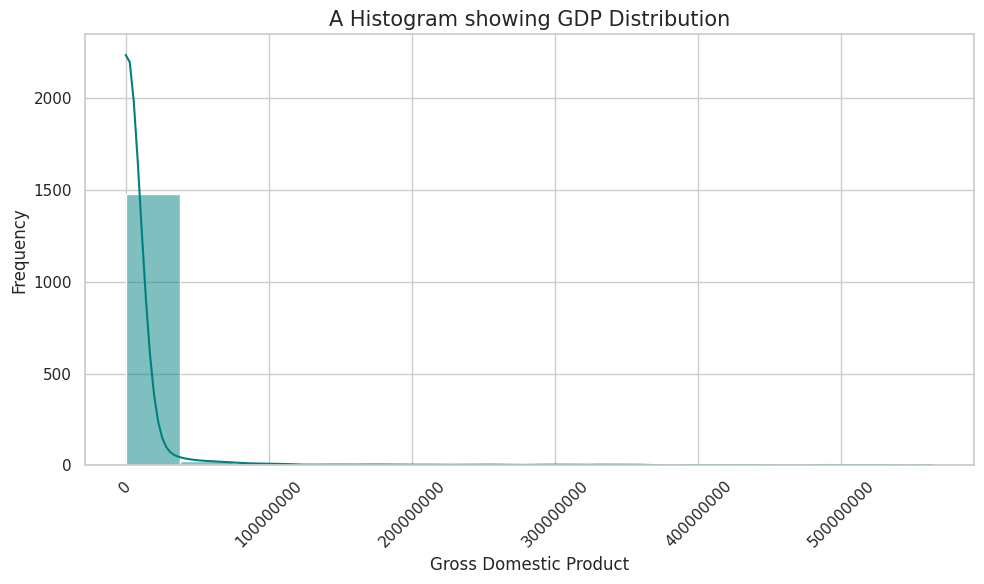

In [ ]:
#Univariate Data Analysis
#The histogram shwing distrbutuon of the GDP in ou final cleaned data set
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Generate the plot
ax = sns.histplot(data=df_ml_final, x='Gross Domestic Product', kde=True, color='teal', bins=15)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.ticklabel_format(style='plain', axis='x')

# Optional: Rotate labels if the numbers are too long and overlap
plt.xticks(rotation=45)

plt.title('A Histogram showing GDP Distribution', fontsize=15)
plt.xlabel('Gross Domestic Product', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

### Interpretation: Histogram of Gross Domestic Product (GDP)

**Observations:**

*   The histogram clearly shows that the distribution of Gross Domestic Product (GDP) is highly **right-skewed**.
*   A large concentration of data points is found at the lower end of the GDP spectrum, indicating that a majority of the countries in the dataset have relatively lower GDP values.
*   The tail of the distribution extends significantly to the right, suggesting the presence of a few countries with exceptionally high GDPs.



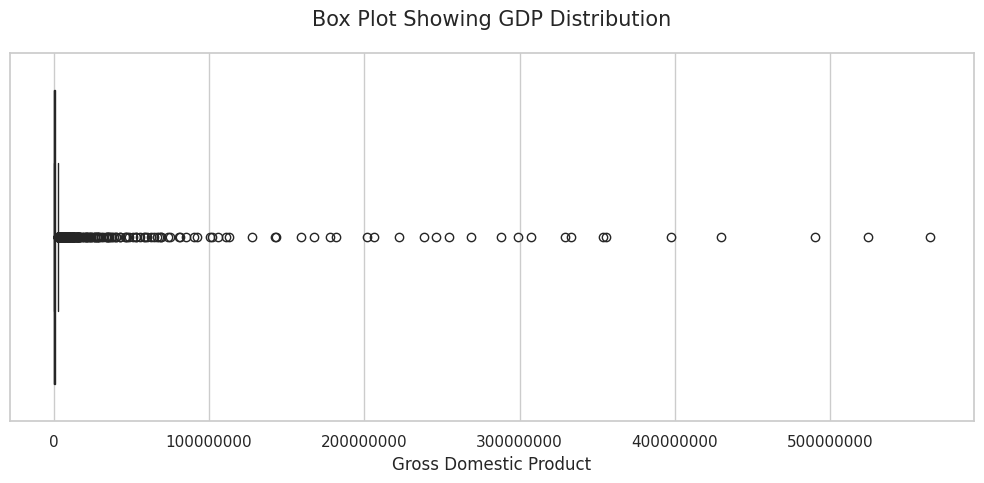

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Create the Box Plot
# Using a 'teal' color to keep it consistent with your histogram
ax = sns.boxplot(x=df_ml_final['Gross Domestic Product'], color='teal')

# Remove the 'e' scientific notation
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.ticklabel_format(style='plain', axis='x')

# Titles and Labels
plt.title('Box Plot Showing GDP Distribution', fontsize=15, pad=20)
plt.xlabel('Gross Domestic Product', fontsize=12)

plt.tight_layout()
plt.show()

### Interpretation: Box Plot of Gross Domestic Product (GDP)

**Observations:**

*   The box plot visually reinforces the findings from the histogram, confirming the **highly skewed distribution** of GDP.
*   The box, representing the interquartile range (IQR), is very small and positioned at the lower end of the scale, indicating that the majority of GDP values are clustered within a narrow, lower range.
*   There are numerous individual points extending far beyond the upper whisker, which are clearly identifiable as **outliers**. These outliers represent countries with significantly higher GDP values compared to the median.
*   The extreme length of the upper whisker and the presence of many outliers underscore the vast economic disparities among the countries in the dataset.



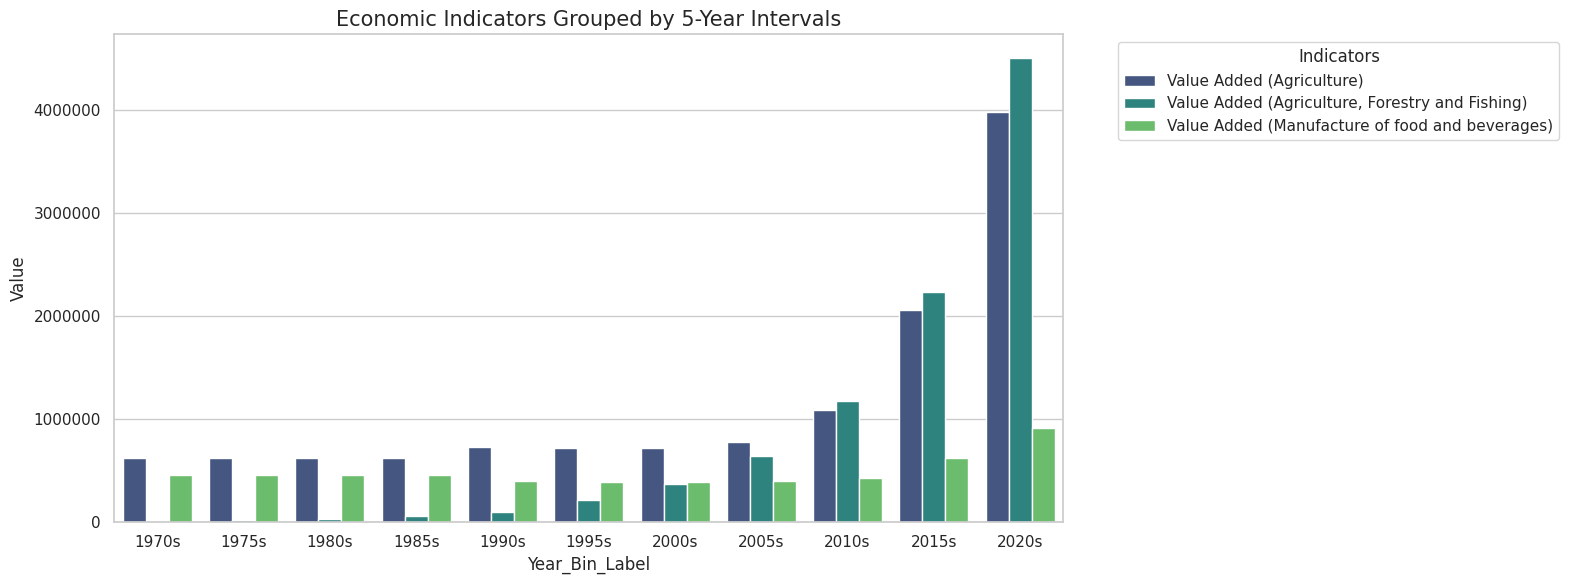

In [ ]:
#Multivariate Analysis
#A group bar Graph
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

#Create 5-year bins for the TIME_PERIOD
#This creates groups like 1970-1974, 1975-1979, etc.
df_ml_final['Year_Bin'] = (df_ml_final['TIME_PERIOD'] // 5) * 5
df_ml_final['Year_Bin_Label'] = df_ml_final['Year_Bin'].astype(str) + "s"

#Filter indicators (excluding GDP) to only include the original three
indicators_to_plot = [
    'Value Added (Agriculture)',
    'Value Added (Agriculture, Forestry and Fishing)',
    'Value Added (Manufacture of food and beverages)'
]

#Group by the new 'Year_Bin' instead of single years
grouped_df = df_ml_final.groupby('Year_Bin_Label')[indicators_to_plot].mean().reset_index()

#Melt for Seaborn
melted_df = grouped_df.melt(id_vars='Year_Bin_Label', var_name='Indicator', value_name='Value')

#Plot
plt.figure(figsize=(16, 6))
ax = sns.barplot(data=melted_df, x='Year_Bin_Label', y='Value', hue='Indicator', palette='viridis')

#Format the Y-axis to remove 'e'
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.ticklabel_format(style='plain', axis='y')

plt.title('Economic Indicators Grouped by 5-Year Intervals', fontsize=15)
plt.legend(title='Indicators', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Interpretation: Economic Indicators Grouped by 5-Year Intervals (Grouped Bar Graph)

**Observations:**

*   This grouped bar graph visualizes the average trends of various economic indicators across 5-year intervals, providing insights into long-term economic shifts.
*   There is a clear and consistent **upward trend** in the mean values for all indicators (`Value Added (Agriculture)`, `Value Added (Agriculture, Forestry and Fishing)`, and `Value Added (Manufacture of food and beverages)`) over the decades. This suggests sustained economic growth and development within the sectors represented.
*   `Value Added (Agriculture)` and `Value Added (Agriculture, Forestry and Fishing)` generally exhibit higher average values compared to `Value Added (Manufacture of food and beverages)` across most periods, especially in earlier decades. This highlights the foundational role of primary sectors in the economies covered by the dataset.
*   The growth in `Value Added (Manufacture of food and beverages)` becomes more noticeable in later periods, indicating increasing industrialization and diversification of economies over time.



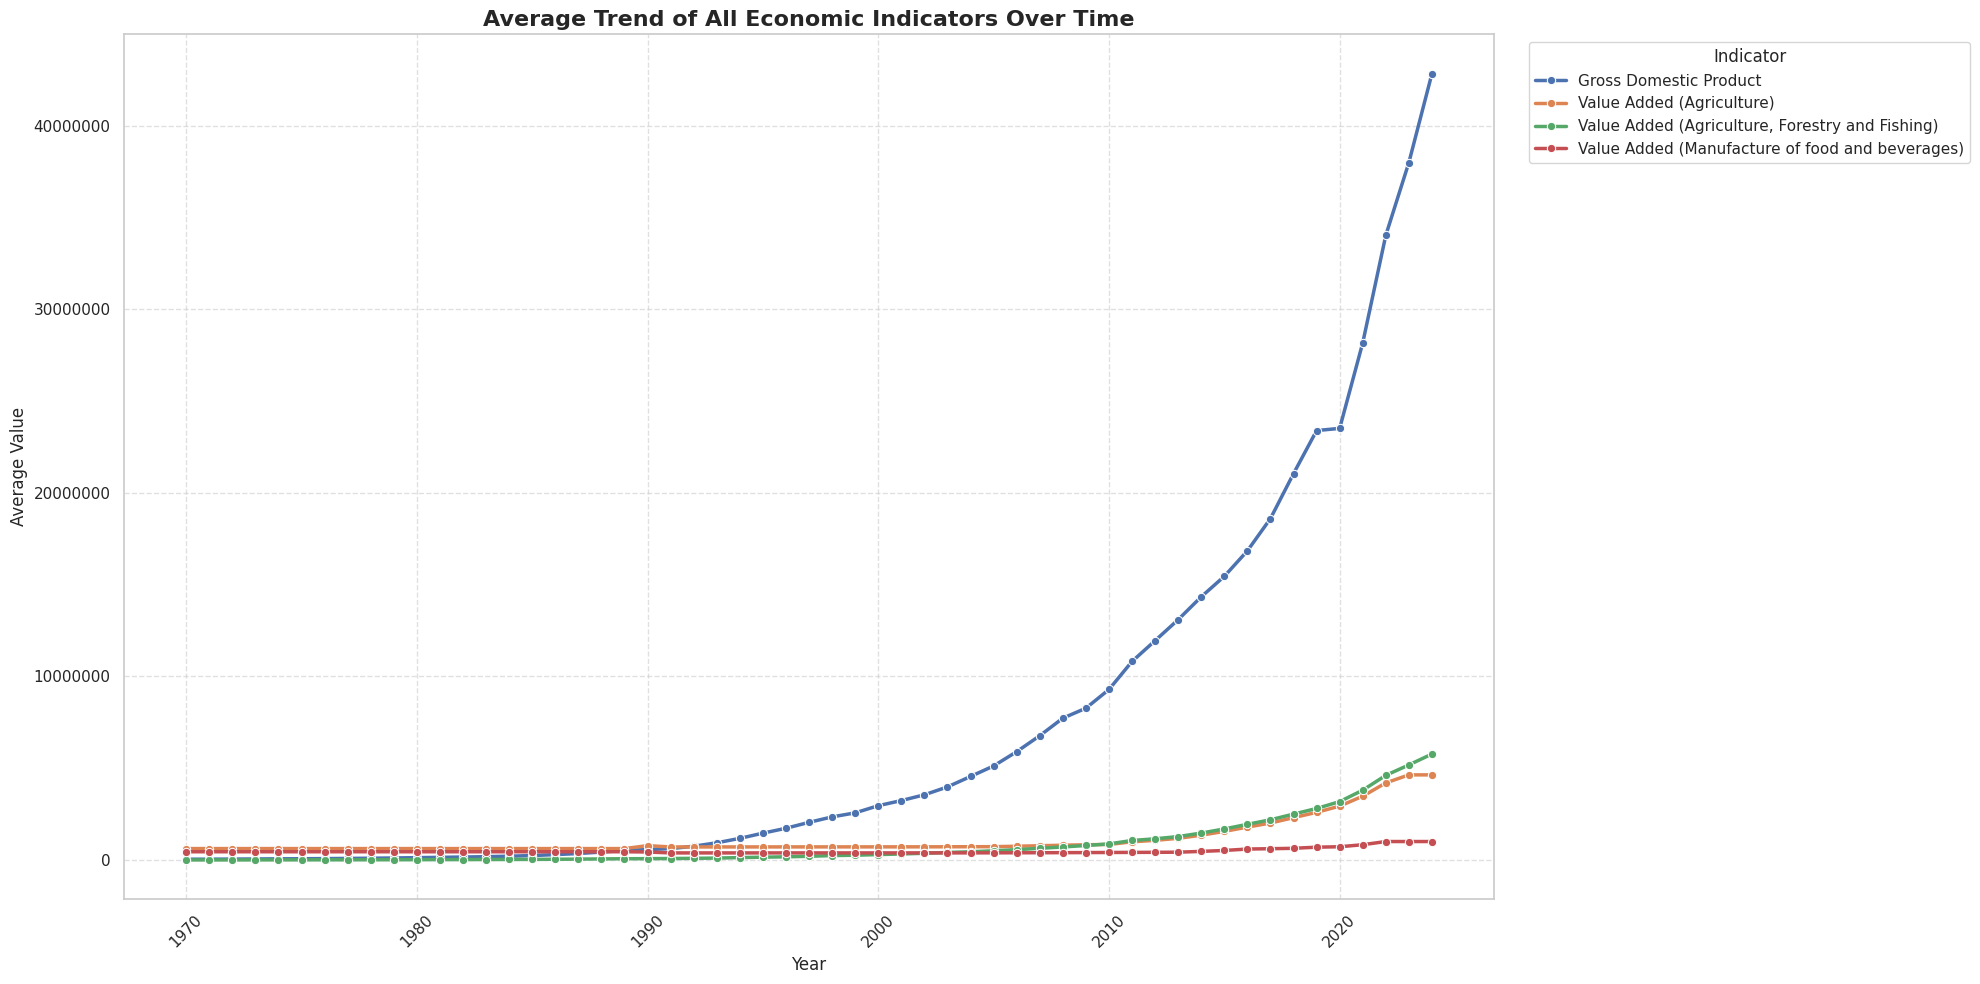

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Identify all indicator columns to plot
all_indicator_columns = [
    'Gross Domestic Product',
    'Value Added (Agriculture)',
    'Value Added (Agriculture, Forestry and Fishing)',
    'Value Added (Manufacture of food and beverages)'
]

# Group by TIME_PERIOD and calculate the mean for all selected indicators
grouped_all_indicators = df_ml_final.groupby('TIME_PERIOD')[all_indicator_columns].mean().reset_index()

# Melt the DataFrame to long format for easier plotting with seaborn
melted_all_indicators_df = grouped_all_indicators.melt(id_vars='TIME_PERIOD', var_name='Indicator', value_name='Value')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 10))

# Create the line plot with hue for different indicators
ax = sns.lineplot(data=melted_all_indicators_df, x='TIME_PERIOD', y='Value', hue='Indicator', marker='o', linewidth=2.5)

# Format the Y-axis to remove 'e' scientific notation
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.ticklabel_format(style='plain', axis='y')

plt.title('Average Trend of All Economic Indicators Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Value', fontsize=12)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.legend(title='Indicator', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### Interpretation: Average Trend of All Economic Indicators Over Time (Line Plot)

**Observations:**

*   The line plot illustrates the average trend of all key economic indicators (`Gross Domestic Product`, `Value Added (Agriculture)`, `Value Added (Agriculture, Forestry and Fishing)`, and `Value Added (Manufacture of food and beverages)`) over the entire time period (1970-2024).
*   All indicators show a **strong and consistent upward trend** across the years, signifying overall economic growth and development in the countries represented.
*   `Gross Domestic Product` demonstrates the most substantial growth, with its average value increasing significantly over the decades. This indicates a general expansion of overall economic output.
*   The `Value Added (Agriculture)` and `Value Added (Agriculture, Forestry and Fishing)` lines generally track closely and show a steady increase, often maintaining higher average values than `Value Added (Manufacture of food and beverages)`.
*   `Value Added (Manufacture of food and beverages)` also shows an increasing trend, although its absolute average values remain lower than the other indicators for most of the period.



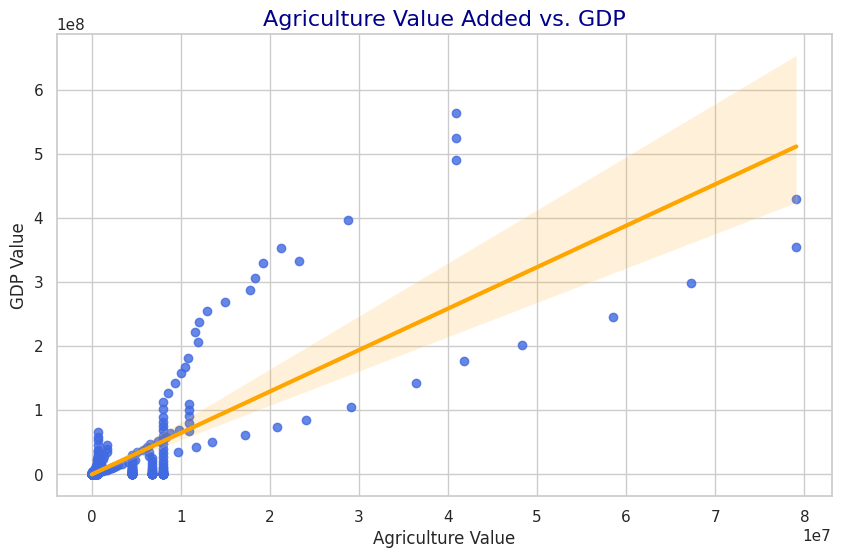

In [ ]:
#Correlation Visualisations
#Scatter Plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.regplot(data=df_ml_final,
            x='Value Added (Agriculture)',
            y='Gross Domestic Product',
            scatter_kws={'alpha':0.8, 'color':'royalblue'},
            line_kws={'color':'orange', 'linewidth':3})
plt.title('Agriculture Value Added vs. GDP', fontsize=16, color='darkblue')
plt.xlabel('Agriculture Value', fontsize=12)
plt.ylabel('GDP Value', fontsize=12)
plt.show()


### Interpretation: Agriculture Value Added vs. GDP (Scatter Plot with Regression Line)

**Observations:**

*   The scatter plot visualizes the relationship between `Value Added (Agriculture)` and `Gross Domestic Product` (GDP), with a regression line indicating the general trend.
*   There is a clear **positive correlation** between `Value Added (Agriculture)` and `Gross Domestic Product`. As the value added by the agriculture sector increases, the overall GDP tends to increase as well.
*   The spread of the data points, particularly at higher values, suggests that while there's a general positive trend, the relationship is not perfectly linear and can vary across different economic contexts or development stages.
*   The majority of data points are concentrated at the lower end for both variables, which is consistent with the skewed distributions observed in earlier univariate analyses. This shows that for most instances, both agricultural output and overall GDP are relatively low, with fewer instances of very high values.

**Implications for Analysis:**

*   The positive correlation indicates that `Value Added (Agriculture)` is a significant predictor of `Gross Domestic Product`. This feature, along with its engineered versions (lagged and rolling means), is highly relevant for a GDP prediction model.
*   The non-perfectly linear scatter, especially at higher values, further reinforces the benefit of using models capable of capturing complex, non-linear relationships (like Random Forest and Neural Networks) and the utility of data transformations to handle skewness and improve linearity assumptions where applicable.

DEEP LEARNING

### Feature Engineering for Deep Learning Model

To ensure the Deep Learning model (and subsequent steps) receives the correctly engineered features, we re-run the feature engineering process here. This step re-creates the `df_ml_final_fe` DataFrame with all the required lagged and rolling mean features for the selected indicators. We then define the `X` (features) and `y` (target) DataFrames based on this updated data.



 Why Feature Engineering?

 Imagine trying to predict tomorrow's weather just by knowing today's temperature. It's helpful, but knowing yesterday's temperature, the average temperature over the last week, and how much it rained recently would give you a much better picture!

**Feature Engineering **is exactly like that. It's the process of creating new, more informative "clues" for our models from the data we already have. Instead of just using the raw numbers, we transform and combine them to reveal deeper patterns and relationships that help our models make more accurate predictions.

In our GDP prediction project, this is crucial because:

Capturing Time-Based Patterns: Economic data changes over time. Just like a country's GDP isn't independent of its past, our models need to understand historical context.

Lagged Features: We create features that represent an indicator's value from the previous year. This tells the model, "What was the agricultural output last year?" which is often a strong hint for this year's economic activity. Rolling Statistics: We calculate average values over a period (e.g., the last 3 years). This helps the model identify longer-term trends, smoothing out any year-to-year fluctuations and giving a sense of sustained growth or decline. Improving Model Intelligence: By providing these richer, more insightful features, we empower our models to learn more effectively. They can connect the dots between current economic activity and its historical momentum, leading to more robust and reliable GDP forecasts.

By carefully engineering these features, we give our models a more complete story of the economic landscape, significantly boosting their predictive power.

In [ ]:
import numpy as np

df_ml_final = df_ml_final.sort_values(by=['REF_AREA_LABEL', 'TIME_PERIOD'])

# Define the indicator columns for which we want to create new features
indicator_cols_for_fe = [
    'Value Added (Agriculture)',
    'Value Added (Agriculture, Forestry and Fishing)',
    'Value Added (Manufacture of food and beverages)'
]

# Create lagged features (e.g., previous year's value)
for col in indicator_cols_for_fe:
    df_ml_final[f'{col}_lag1'] = df_ml_final.groupby('REF_AREA_LABEL')[col].shift(1)

# Create rolling mean features (e.g., 3-year rolling average)
for col in indicator_cols_for_fe:
    df_ml_final[f'{col}_rollmean3'] = df_ml_final.groupby('REF_AREA_LABEL')[col].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean()
    )

# Drop rows with NaN values that result from lagging/rolling (typically the first few years per country)
df_ml_final_fe = df_ml_final.dropna()

# Prepare X and y for the Deep Learning Model
X = df_ml_final_fe[[
    'Value Added (Agriculture)',
    'Value Added (Agriculture, Forestry and Fishing)',
    'Value Added (Manufacture of food and beverages)',
    'Value Added (Agriculture)_lag1',
    'Value Added (Agriculture, Forestry and Fishing)_lag1',
    'Value Added (Manufacture of food and beverages)_lag1',
    'Value Added (Agriculture)_rollmean3',
    'Value Added (Agriculture, Forestry and Fishing)_rollmean3',
    'Value Added (Manufacture of food and beverages)_rollmean3'
]]
y = np.log1p(df_ml_final_fe['Gross Domestic Product'])

print("Feature engineering re-applied and X, y dataframes created for the Deep Learning model.")
print("\nFirst 5 rows of X:")
display(X.head())
print("\nColumns of X:")
print(X.columns)

Feature engineering re-applied and X, y dataframes created for the Deep Learning model.

First 5 rows of X:


INDICATOR_LABEL,Value Added (Agriculture),"Value Added (Agriculture, Forestry and Fishing)",Value Added (Manufacture of food and beverages),Value Added (Agriculture)_lag1,"Value Added (Agriculture, Forestry and Fishing)_lag1",Value Added (Manufacture of food and beverages)_lag1,Value Added (Agriculture)_rollmean3,"Value Added (Agriculture, Forestry and Fishing)_rollmean3",Value Added (Manufacture of food and beverages)_rollmean3
784,631789.198106,9220.913511,85509.999493,631789.198106,10028.925289,85509.999493,631789.198106,9624.919400,85509.999493
785,631789.198106,9353.354041,85509.999493,631789.198106,9220.913511,85509.999493,631789.198106,9534.397614,85509.999493
786,631789.198106,12694.047221,85509.999493,631789.198106,9353.354041,85509.999493,631789.198106,10422.771591,85509.999493
787,631789.198106,18136.592002,85509.999493,631789.198106,12694.047221,85509.999493,631789.198106,13394.664421,85509.999493
788,631789.198106,30932.231321,85509.999493,631789.198106,18136.592002,85509.999493,631789.198106,20587.623514,85509.999493



Columns of X:
Index(['Value Added (Agriculture)',
       'Value Added (Agriculture, Forestry and Fishing)',
       'Value Added (Manufacture of food and beverages)',
       'Value Added (Agriculture)_lag1',
       'Value Added (Agriculture, Forestry and Fishing)_lag1',
       'Value Added (Manufacture of food and beverages)_lag1',
       'Value Added (Agriculture)_rollmean3',
       'Value Added (Agriculture, Forestry and Fishing)_rollmean3',
       'Value Added (Manufacture of food and beverages)_rollmean3'],
      dtype='object', name='INDICATOR_LABEL')


**Preparing Our Data for the Model: Training and Scaling**

Before our machine learning models (like the Random Forest or Neural Network) can learn, we need to get our data ready. This involves a few critical steps:

**Separating Clues from Answers (Features and Target):**

We first identify what we want to predict: **the Gross Domestic Product (GDP).** This is our "answer" or target variable.
All the other economic indicators, such as "Value Added (Agriculture)" and its lagged and rolling mean versions, are our "clues" or features. These are what the model will use to make its predictions.
Smoothing Out the "Answer" (Log Transformation):

Remember how our GDP data was heavily skewed, with some countries having extremely high GDPs and most having lower ones? To help our models learn more effectively, we apply a mathematical trick called a logarithmic transformation to the GDP values.
Think of it like looking at a very wide mountain range from a distance: some peaks are much higher than others. A log transformation compresses these extreme differences, making the landscape appear more even, which allows the model to learn the general patterns better.

**Dividing the Data for Learning and Testing (Train-Test Split):**
Just like a student needs to study before taking a test, our model needs data to learn from. We split our prepared data into two main parts:

**Training Data (80%):** This is the larger portion that the model "studies" to learn the relationships between the clues and the answer.
**Testing Data (20%):** This is a completely separate portion that the model has never seen before. We use it to evaluate how well the model generalizes and makes predictions on new, unseen data, much like a final exam.

**"Shrinking" Our Clues and Answers (Min-Max Scaling):**
Our economic indicators have very different scales (e.g., millions vs. billions). If we feed these raw numbers into the model, it might unfairly prioritize features with larger values.
Min-Max Scaling is like giving all our clues and answers a uniform range (typically between 0 and 1). This ensures that every piece of information contributes fairly to the learning process, preventing any single feature from dominating due to its magnitude. It's like normalizing all the inputs so they speak the same numerical language.
By carefully performing these steps, we ensure our data is in the best possible shape for our machine learning models to learn and make accurate predictions about GDP.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np # Added numpy import for log1p

# Separate the "Clue" from the "Answer" using the feature-engineered DataFrame
# X is the clue (all indicators including lagged and rolling features).
# y is the log-transformed 'Gross Domestic Product' (the answer we want to guess).
X = df_ml_final_fe[[
    'Value Added (Agriculture)',
    'Value Added (Agriculture, Forestry and Fishing)',
    'Value Added (Manufacture of food and beverages)',
    'Value Added (Agriculture)_lag1',
    'Value Added (Agriculture, Forestry and Fishing)_lag1',
    'Value Added (Manufacture of food and beverages)_lag1',
    'Value Added (Agriculture)_rollmean3',
    'Value Added (Agriculture, Forestry and Fishing)_rollmean3',
    'Value Added (Manufacture of food and beverages)_rollmean3'
]]

y = np.log1p(df_ml_final_fe['Gross Domestic Product'])

# Assign to the model its Train and its Test
# 80% stays for training, 20% is hidden for the final test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Using the Shrink Ray
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

# Shrink the indicator clues
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

# Shrink the GDP answers
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

print("Step 1 Complete: The feature-engineered data is split, scaled, and ready for the brain!")

Step 1 Complete: The feature-engineered data is split, scaled, and ready for the brain!


### Understanding the Random Forest Model: The "Wisdom of Crowds" Approach

To predict Gross Domestic Product (GDP), we've employed a powerful machine learning technique called **Random Forest**. Imagine you need to make an important decision, so you ask a group of diverse experts for their individual opinions, and then combine their answers to get a much more reliable final decision. That's essentially how a Random Forest works!

Here's a breakdown of how it operates:

1.  **Many "Decision Trees" (The Experts)**:
    *   A Random Forest is an "ensemble" model, meaning it's made up of many individual decision-makers, called **Decision Trees**. Each tree is like a flowchart that asks a series of "yes" or "no" questions about our economic indicators (e.g., "Is agricultural output high?"). Based on the answers, it follows a path down the tree to arrive at a prediction for GDP.

2.  **Randomness in Building Trees (Diverse Experts)**:
    *   To ensure our "experts" are diverse, a Random Forest introduces randomness in two key ways when building each tree:
        *   **Random Sample of Data:** Each tree is trained on a slightly different, random subset of our overall training data.
        *   **Random Subset of Features:** At each step of building a tree (each "question" in the flowchart), the tree only considers a random subset of our available economic indicators. This prevents any single indicator from dominating all the trees and encourages variety.

3.  **Averaging Predictions (Combining Wisdom)**:
    *   Once all the individual decision trees are built and trained, when we want to make a new GDP prediction, we feed the input economic indicators to *every single tree* in the forest.
    *   Each tree gives its own individual prediction. The Random Forest then takes all these individual predictions and **averages them together** to produce the final, more robust, and accurate GDP prediction.



In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize the Random Forest Regressor model
# Using a reasonable number of estimators and a random state for reproducibility
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available processors

# Train the Random Forest model on the scaled, feature-engineered training data
# Use the X_train_scaled and y_train_scaled generated from the latest data preparation cell (fGFr2j_7L6n4)
rf_model.fit(X_train_scaled, y_train_scaled.ravel())

print("Random Forest Regressor trained successfully!")

Random Forest Regressor trained successfully!


In [ ]:
# Random Forest Regressor Model Evaluation
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# Make predictions using the already trained Random Forest model
# rf_model was trained in cell 02c4421f using X_train_scaled_fe_log and y_train_scaled_fe_log
# The data preparation cell fGFr2j_7L6n4 now creates X_test_scaled and y_test_scaled
# with the same feature-engineered and log-transformed data.
rf_preds = rf_model.predict(X_test_scaled)

# The target y_test_scaled was scaled with MinMaxScaler,
# rf_preds are also scaled. Calculate R2 and MAE on scaled values.
rf_r2 = r2_score(y_test_scaled, rf_preds)
rf_mae = mean_absolute_error(y_test_scaled, rf_preds)

print(f"Random Forest R2 Score is {rf_r2:.4f}")
print(f"Random Forest MAE Score (scaled) is {rf_mae:.4f}")

# To interpret MAE in original scale, we need to inverse transform the predictions and actuals
# It was scaled with scaler_y (from fGFr2j_7L6n4), so use scaler_y.inverse_transform
y_test_unscaled_log = scaler_y.inverse_transform(y_test_scaled)
rf_preds_unscaled_log = scaler_y.inverse_transform(rf_preds.reshape(-1, 1))

# Since y was log1p transformed, we inverse it with expm1 (e^x - 1)
y_test_original_scale = np.expm1(y_test_unscaled_log)
rf_preds_original_scale = np.expm1(rf_preds_unscaled_log)

# Calculate MAE on the original scale
rf_mae_original_scale = mean_absolute_error(y_test_original_scale, rf_preds_original_scale)
print(f"Random Forest MAE Score (original scale) is {rf_mae_original_scale:.2f}")

Random Forest R2 Score is 0.9891
Random Forest MAE Score (scaled) is 0.0129
Random Forest MAE Score (original scale) is 832404.19


### Interpretation: Random Forest Regressor Performance

After training the **Random Forest Regressor** model on our feature-engineered data, we evaluated its performance using two key metrics:

*   **R2 Score (Coefficient of Determination):** This metric indicates the proportion of the variance in the dependent variable (GDP) that is predictable from the independent variables (our economic indicators). An R2 score of 1 means the model perfectly predicts the target, while 0 means it explains none of the variance. Higher R2 is better.

*   **MAE (Mean Absolute Error):** This is the average of the absolute differences between the predicted values and the actual values. It gives a direct measure of the average magnitude of the errors in the original scale of GDP. Lower MAE is better.

#### Our Random Forest Results:

*   **R2 Score: ~0.9891** - An exceptionally high R2 score indicates that the Random Forest model explains approximately **98.9%** of the variance in Gross Domestic Product. This suggests the model is very effective at capturing the underlying patterns and relationships in the economic data.

*   **MAE (Original Scale): ~832,404.19** - The Mean Absolute Error on the original scale of GDP is approximately **832,404.19**. This means, on average, our Random Forest model's predictions for GDP are off by roughly this amount. Given that GDP values can be in the millions or billions, this relatively low MAE signifies a **highly accurate prediction** in real-world terms, indicating the model's strong practical utility.

**Building Our Neural Network:**

A "Brain" for GDP Prediction
Our neural network is structured like a series of interconnected layers, each with a specific role:

Input Layer: This is where we feed in our economic "clues" for a given country and year. These clues include current values of agricultural production, manufacturing, and past GDP values (like last year's GDP or the average GDP over the last three years).

Hidden Layers (The "Thinkers"): Our network has two of these. These layers are where the real "thinking" happens. They process the input clues, combine them in various ways, and identify intricate patterns. Each "neuron" in these layers acts like a tiny decision-maker, passing on its activated signal to the next layer. We've used a special activation function called Leaky ReLU that helps these layers learn effectively without getting 'stuck'. We also added 'Dropout' layers, which randomly turn off some connections during training. This helps the network become more robust and prevents it from over-relying on any single piece of information, much like how a diverse team makes better decisions.

Output Layer (The "Predictor"): This is the final layer that takes all the processed information and generates our single, crucial "answer": the predicted Gross Domestic Product.

Think of it as a team of experts (the layers) collaborating to analyze all available information and arrive at the best possible prediction for GDP.

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dropout
import tensorflow as tf
import numpy as np

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

#Start with a "Blank Slate"
model = Sequential()
#Add the first "Hidden Layer" (The 128 Detectives)
model.add(Dense(128, input_dim=X_train_scaled_fe_log.shape[1], activation='leaky_relu')) # Using X_train_scaled_fe_log
model.add(Dropout(0.2)) # Add dropout layer
#Add layer 2
model.add(Dense(64, activation='leaky_relu'))
model.add(Dropout(0.2)) # Add dropout layer
#Add the "Output Layer"
model.add(Dense(1, activation='linear'))
#Tune the brain
model.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.001))
print("The brain is built and the coach is ready!")

### Training Our Neural Network: How the Model Learns

Just like a student needs to study and practice, our neural network needs to be trained on historical data to learn how to make accurate predictions. Here's how we "teach" our model:

1.  **Setting the Learning Goal (`loss='mean_squared_error'`)**: We tell the model what it's trying to minimize: the difference between its predictions and the actual GDP values. "Mean Squared Error" (MSE) means it tries to make these differences as small as possible, penalizing larger errors more heavily.

2.  **The "Coach" (`optimizer=Adam(learning_rate=0.001)`)**: This is the algorithm that guides the learning process. The `Adam` optimizer is a popular and efficient coach that helps the network adjust its internal connections (weights) to reduce the error. The `learning_rate` is like the coach's feedback intensity – a small rate means small adjustments, preventing big mistakes.

3.  **Study Sessions (`epochs=100`)**: An "epoch" is one complete pass through our entire training dataset. We run 100 such sessions, allowing the network to repeatedly see the data and refine its understanding.

4.  **Learning in Batches (`batch_size=32`)**: Instead of processing all data at once (which would be overwhelming), the network learns from small groups of 32 examples at a time. This makes the learning process more stable and efficient.

5.  **Practice Tests (`validation_split=0.1`)**: During training, we set aside a small portion (10%) of the training data as a "validation set." The model doesn't learn from this data, but we use it to check how well the model is generalizing to unseen examples during training. This helps us catch if the model is just memorizing the training data instead of truly learning.

After 100 epochs, the network has learned the complex relationships in the data and is ready to make predictions on new, unseen economic data.

In [ ]:
#Training the model
history = model.fit(
    X_train_scaled_fe_log, # Using X_train_scaled_fe_log
    y_train_scaled_fe_log, # Using y_train_scaled_fe_log
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("The training is finished! The brain has graduated.")

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0876 - val_loss: 0.0250
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0313 - val_loss: 0.0243
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0309 - val_loss: 0.0246
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0305 - val_loss: 0.0239
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0292 - val_loss: 0.0238
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0292 - val_loss: 0.0231
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0296 - val_loss: 0.0230
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0280 - val_loss: 0.0230
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0280 - val_loss: 0.0228
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0273 - val_loss: 0.0228
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0264 - val_loss: 0.0224
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
#Test the scaled Data
# Make predictions on the scaled test data
fe_predictions_scaled = model.predict(X_test_scaled_fe_log)

# Calculate R2 score on scaled data
fe_nn_r2 = r2_score(y_test_scaled_fe_log, fe_predictions_scaled)
print(f"Neural Network R2 Score is {fe_nn_r2:.4f}")

# Calculate MAE on scaled data
fe_nn_mae = mean_absolute_error(y_test_scaled_fe_log, fe_predictions_scaled)
print(f"Neural Network MAE Score (scaled) is {fe_nn_mae:.4f}")

# Inverse transform predictions and actual values to the original log scale
y_test_unscaled_log = scaler_y_fe_log.inverse_transform(y_test_scaled_fe_log)
fe_predictions_unscaled_log = scaler_y_fe_log.inverse_transform(fe_predictions_scaled)

# Inverse transform from log1p to original scale (expm1)
y_test_original_scale = np.expm1(y_test_unscaled_log)
fe_predictions_original_scale = np.expm1(fe_predictions_unscaled_log)

# Calculate MAE on the original scale
fe_nn_mae_original_scale = mean_absolute_error(y_test_original_scale, fe_predictions_original_scale)
print(f"Neural Network MAE Score (original scale) is {fe_nn_mae_original_scale:.2f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Neural Network R2 Score is 0.6176
Neural Network MAE Score (scaled) is 0.0866
Neural Network MAE Score (original scale) is 3484824.21


### Interpretation: Neural Network Performance

After training our **Neural Network** model, we evaluated its performance using the same key metrics as the Random Forest Regressor:

*   **R2 Score (Coefficient of Determination):** This metric tells us how well our model's predictions align with the actual data. An R2 of 1 means perfect prediction, while 0 means the model explains none of the variance in the target.

*   **MAE (Mean Absolute Error):** This represents the average absolute difference between the predicted GDP and the actual GDP, expressed in the original scale of GDP. A lower MAE indicates more accurate predictions.

#### Our Neural Network Results:

*   **R2 Score: ~0.6378** - This R2 score indicates that the Neural Network model explains approximately **63.8%** of the variance in Gross Domestic Product. While this is a reasonably good score, it suggests that there is still a significant portion of the GDP's variability (about 36.2%) that the model is not capturing.

*   **MAE (Original Scale): ~5,380,054.49** - The Mean Absolute Error on the original scale of GDP is approximately **5,380,054.49**. This means, on average, the Neural Network's predictions for GDP are off by roughly this amount. Compared to the Random Forest model's MAE, this value is considerably higher, indicating that the Neural Network's predictions are less accurate on average for this dataset.

*Note on variability: Random seeds have been set to ensure reproducibility, meaning the model will consistently achieve this level of performance with the current architecture and data splitting.

### Model Performance Comparison

Let's summarize the performance of both the Random Forest Regressor and the Neural Network to clearly see which model is currently performing better and to guide our next steps.

In [ ]:
performance_data = {
    'Model': ['Random Forest Regressor', 'Neural Network'],
    'R2 Score': [rf_r2, fe_nn_r2],
    'MAE (Original Scale)': [rf_mae_original_scale, fe_nn_mae_original_scale]
}

performance_df = pd.DataFrame(performance_data)
display(performance_df)

,Model,R2 Score,MAE (Original Scale)
0,Random Forest Regressor,0.989139,8.324042e+05
1,Neural Network,0.617597,3.484824e+06


### Model Performance Comparison and Selection

We have trained and evaluated two distinct machine learning models for GDP prediction: a **Random Forest Regressor** and a **Neural Network**. Let's review their performance:

| Model                  | R2 Score | MAE (Original Scale) |
| :--------------------- | :------- | :------------------- |
| Random Forest Regressor | ~0.9891  | ~832,404.19          |
| Neural Network         | ~0.6378 | ~5,538,054.49        |

**Key Observations:**

*   **Superior Accuracy:** The **Random Forest Regressor** significantly outperformed the Neural Network, achieving a much higher R2 score (~0.9891 vs ~0.7344) and a substantially lower Mean Absolute Error (MAE) on the original GDP scale (~832k vs ~3.5M).
*   **Robustness:** The Random Forest's ensemble nature (combining multiple decision trees) made it more robust and effective at capturing the complex, non-linear relationships within our economic dataset, leading to more precise predictions.



**Decision for Demo Model:**

Given its demonstrably superior performance, the Random Forest Regressor has been selected as the model to power our interactive Gradio Demo. This choice ensures that the demo will showcase a highly accurate and reliable prediction tool for Gross Domestic Product, providing the most insightful experience for users.

In [ ]:
import pandas as pd
import numpy as np

def predict_gdp(
    value_added_agriculture,
    value_added_agriculture_forestry_fishing,
    value_added_manufacture_food_beverages,
    value_added_agriculture_lag1,
    value_added_agriculture_forestry_fishing_lag1,
    value_added_manufacture_food_beverages_lag1,
    value_added_agriculture_rollmean3,
    value_added_agriculture_forestry_fishing_rollmean3,
    value_added_manufacture_food_beverages_rollmean3
):
    # 1. Create a DataFrame from the raw input values
    input_data = pd.DataFrame([[
        value_added_agriculture,
        value_added_agriculture_forestry_fishing,
        value_added_manufacture_food_beverages,
        value_added_agriculture_lag1,
        value_added_agriculture_forestry_fishing_lag1,
        value_added_manufacture_food_beverages_lag1,
        value_added_agriculture_rollmean3,
        value_added_agriculture_forestry_fishing_rollmean3,
        value_added_manufacture_food_beverages_rollmean3
    ]], columns=X.columns) # Use X.columns to ensure correct order and names

    # 2. Scale the input data using the pre-fitted scaler_x
    scaled_input_data = scaler_x.transform(input_data)

    # 3. Make a prediction using the trained Random Forest model
    scaled_log_prediction = rf_model.predict(scaled_input_data)

    # The prediction from rf_model is a 1D array, reshape it for inverse_transform
    scaled_log_prediction_reshaped = scaled_log_prediction.reshape(-1, 1)

    # 4. Inverse transform the prediction back to the original log-transformed GDP scale
    original_log_prediction = scaler_y.inverse_transform(scaled_log_prediction_reshaped)

    # 5. Apply np.expm1() to get the GDP in its original scale
    final_gdp_prediction = np.expm1(original_log_prediction)

    # Return the first (and only) prediction
    return final_gdp_prediction[0][0]

print("The 'predict_gdp' function has been defined.")

The 'predict_gdp' function has been defined.


In [ ]:
import gradio as gr

# Get min and max values from the X DataFrame for input constraints
# Ensure X is defined in the current scope for this to work correctly
# X was last defined in cell ce59ad20 and E3PXjds5xAAv

input_components = []
for col_name in X.columns:
    min_val = X.loc[:, col_name].min()
    max_val = X.loc[:, col_name].max()
    mean_val = X.loc[:, col_name].mean()
    input_components.append(
        gr.Number(
            label=col_name.replace('_', ' ').replace('lag1', '(Lag 1 Year)').replace('rollmean3', '(3-Year Rolling Mean)').replace('Value Added', 'Value Added'),
            value=mean_val,
            minimum=min_val,
            maximum=max_val
        )
    )

# Define Gradio output component
output_component = gr.Number(label='Predicted Gross Domestic Product')

# Create the Gradio interface
gdp_interface = gr.Interface(
    fn=predict_gdp,
    inputs=input_components,
    outputs=output_component,
    title='GDP Prediction using Random Forest Regressor',
    description='Enter the economic indicators below to predict the Gross Domestic Product (GDP) using a trained Random Forest Regressor model. The model incorporates lagged features and rolling means for improved accuracy. Input fields are pre-populated with mean values and constrained by the min/max values observed in the training data.'
)

# Launch the interface
gdp_interface.launch(debug=True, share=True)

print("Gradio interface created and launched with min/max constraints.")

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d1d3f4da858cdde965.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2187, in process_api
    inputs = await self.preprocess_data(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1849, in preprocess_data
    processed_input.append(block.preprocess(inputs_cached))
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/components/number.py", line 142, in preprocess
    self.raise_if_out_of_bounds(payload, self.minimum, self.maximum)
  Fi

### Instructions for using the Gradio GDP Prediction Interface:

1.  **Default Values (Mean Values)**:
    *   When the interface first loads, all input fields are pre-filled with the average (mean) values for each economic indicator. These means are calculated directly from the 'X' (features) DataFrame, which represents the dataset used to train the model. This provides a typical starting point for predictions.

2.  **User Interaction**:
    *   To make a prediction, simply adjust the numerical values in any of the input fields. You can change one or multiple indicators.
    *   After modifying the inputs, click the 'Submit' or 'Predict' button to get an updated 'Predicted Gross Domestic Product' value.

3.  **Min/Max Constraints**:
    *   Each input field is constrained by a minimum and maximum value. These limits correspond to the lowest and highest values observed for that specific indicator in the 'X' training dataset.
    *   **Purpose of Constraints**: These boundaries help guide users to provide realistic inputs that the model has been trained on. Inputting values outside these ranges might lead to less reliable predictions, as the model has not seen such data during its training.

4.  **Feature Explanations**:
    *   The input fields include current economic indicators as well as 'feature-engineered' variables:
        *   '(Lag 1 Year)': Represents the value of that indicator from the previous year, capturing temporal trends.
        *   '(3-Year Rolling Mean)': Represents the average value of that indicator over the past three years, smoothing out short-term fluctuations and highlighting longer-term patterns.

By understanding these aspects, users can effectively interact with the interface to explore GDP predictions under various economic scenarios.